# M2 三组训练结果复核

该 notebook 从本地 TensorBoard、checkpoint 与 provenance 原始文件重建指标、完整性表、比较表和图表。A1 是历史参考；R1/R2/R3 是本批三个训练。

In [1]:
from pathlib import Path
from IPython.display import display, Image
from tools.analyze_m2_three_runs import run_analysis

repo_root = Path.cwd()
outputs = run_analysis(repo_root, write_notebook=False)
print('Analysis outputs regenerated.')

Analysis outputs regenerated.


## 完整性与最终指标

In [2]:
display(outputs['integrity'][[
    'run_id', 'integrity_status', 'git_commit', 'checkpoint_global_step',
    'success_points', 'precision_points', 'loss_points', 'checkpoint_sha256'
]])
display(outputs['summary'].round(4))

,run_id,integrity_status,git_commit,checkpoint_global_step,success_points,precision_points,loss_points,checkpoint_sha256
0,A1,PASS,None,75720,12,12,75720,a2fbffb1e5acae37adab3cb858e864857cc1d6c2231f9e...
1,R1,PASS,473738fa2cf3def246e4e6b1bce35d8692c416c7,75720,12,12,75720,362b3314ad056f289509818606af30fcc43d2331eb9156...
2,R2,PASS,473738fa2cf3def246e4e6b1bce35d8692c416c7,75720,12,12,75720,00a10b88b6a33c77ba26b2b8f064992e0d8eddd3a92ba3...
3,R3,PASS,473738fa2cf3def246e4e6b1bce35d8692c416c7,75720,12,12,75720,d1ce4ea8cbe86263197d3d934548f6e72d5f57cccb6472...


,run_id,run_label,initialization,method,evidence_role,validation_points,final_success,best_success,best_success_epoch,late_mean_success,all_eval_mean_success,final_precision,best_precision,best_precision_epoch,late_mean_precision,all_eval_mean_precision
0,A1,A1 historical baseline,scratch,A1 / SeqTrack3D order-time,historical reference,12,51.2287,53.2987,45,50.9748,49.0018,57.8632,62.0153,45,58.1232,56.9589
1,R1,R1 A1-init M2,A1 last.ckpt,M2 proposal innovation,primary formal run,12,55.3031,55.6488,40,54.6768,50.7595,67.1816,67.6849,50,66.5140,61.2229
2,R2,R2 scratch M2,scratch,M2 proposal innovation,scratch method control,12,53.3184,53.3184,60,51.8943,48.0057,62.5033,65.3567,30,60.2536,55.5264
3,R3,R3 scratch W0,scratch,W0 without M2,matched shared-SE(2) control,12,28.9989,35.7582,10,27.6637,27.9958,28.0230,39.3687,10,26.4880,28.1052


## 主要比较与可归因性限制

In [3]:
display(outputs['comparisons'][outputs['comparisons']['scope'] == 'final'].round(4))
display(outputs['config_diff'])

,comparison,treatment_run,control_run,scope,metric,treatment_value,control_value,delta,interpretation_status,caveat
0,R1 minus A1,R1,A1,final,Success,55.3031,51.2287,4.0744,descriptive_only,M2 effect is confounded with another 60 epochs...
1,R1 minus A1,R1,A1,final,Precision,67.1816,57.8632,9.3184,descriptive_only,M2 effect is confounded with another 60 epochs...
4,R2 minus R3,R2,R3,final,Success,53.3184,28.9989,24.3195,matched_scratch_control,"Same commit/seed/steps/data and shared-SE(2), ..."
5,R2 minus R3,R2,R3,final,Precision,62.5033,28.0230,34.4803,matched_scratch_control,"Same commit/seed/steps/data and shared-SE(2), ..."
8,R2 minus A1,R2,A1,final,Success,53.3184,51.2287,2.0897,historical_cross_run,"Promising reference comparison, not fully matc..."
9,R2 minus A1,R2,A1,final,Precision,62.5033,57.8632,4.6400,historical_cross_run,"Promising reference comparison, not fully matc..."


,field,A1,R1,R2,R3
0,candidate_trajectory_mode,legacy per-candidate (field absent),shared_se2,shared_se2,shared_se2
1,use_dynamics_encoder,False,True,True,False
2,use_physical_time_adapter,False,True,True,False
3,dynamics_motion_mode,feature,proposal_innovation,proposal_innovation,feature
4,dynamics_time_mode,not available in legacy run,true,true,true
5,dynamics_innovation_alpha,n/a,0.75,0.75,0.75
6,dynamics_innovation_warmup_epoch,n/a,5,5,5
7,velocity_weight,0.05,0.05,0.05,0.0
8,dynamics_displacement_weight,0.0,0.01,0.01,0.0
9,seed,42,42,42,42


## 图表

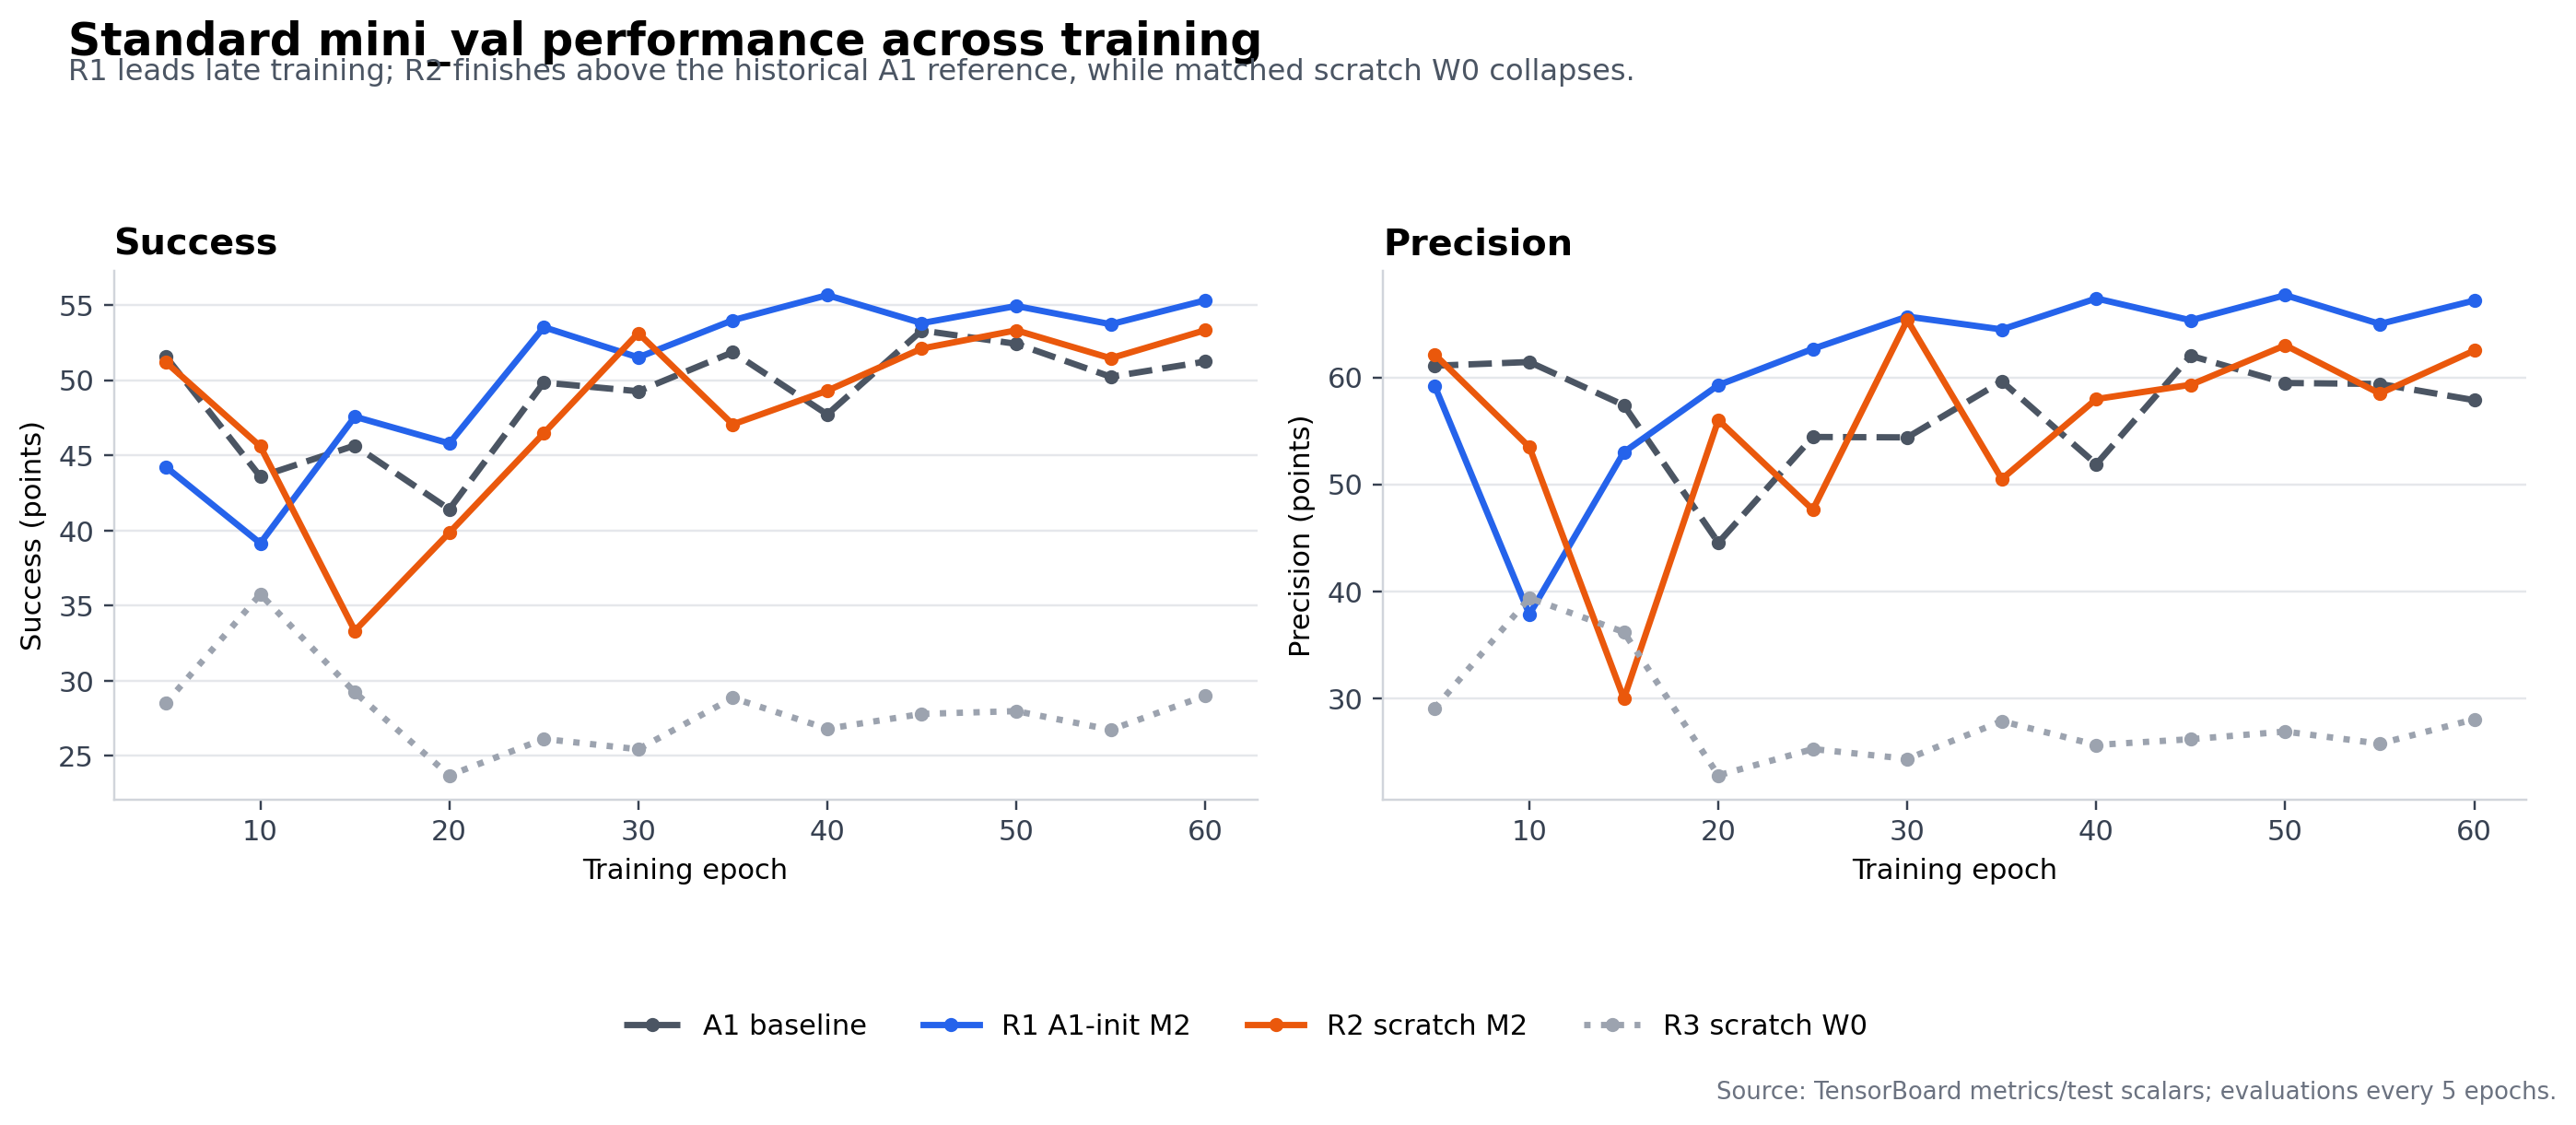

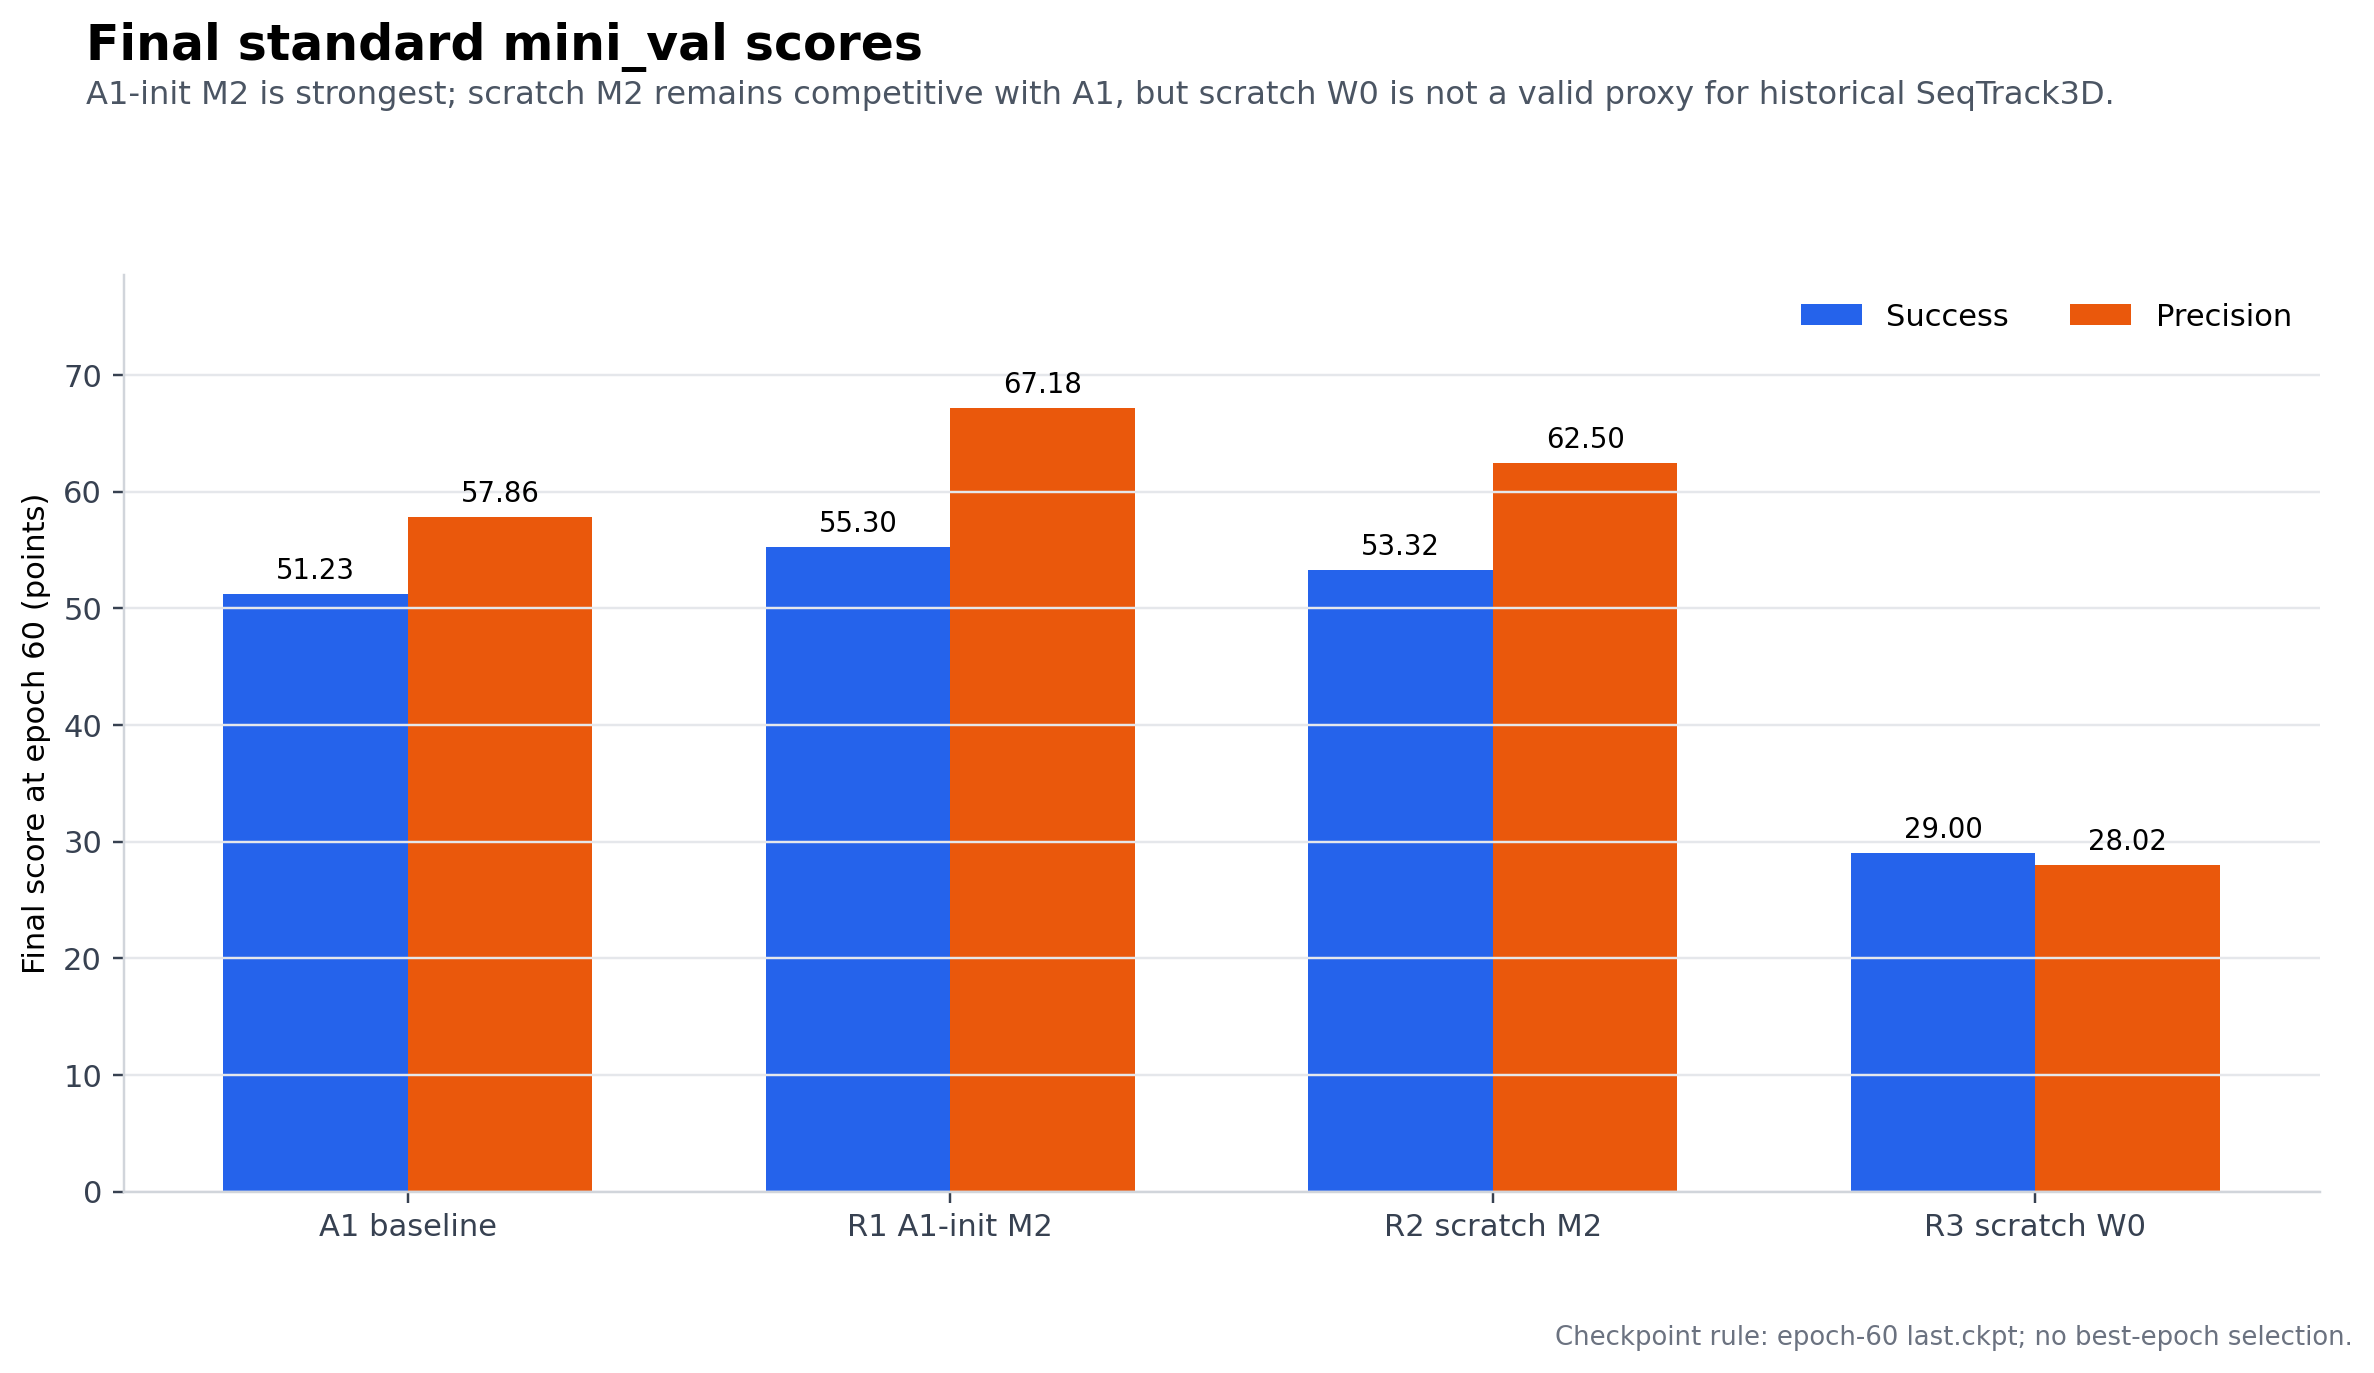

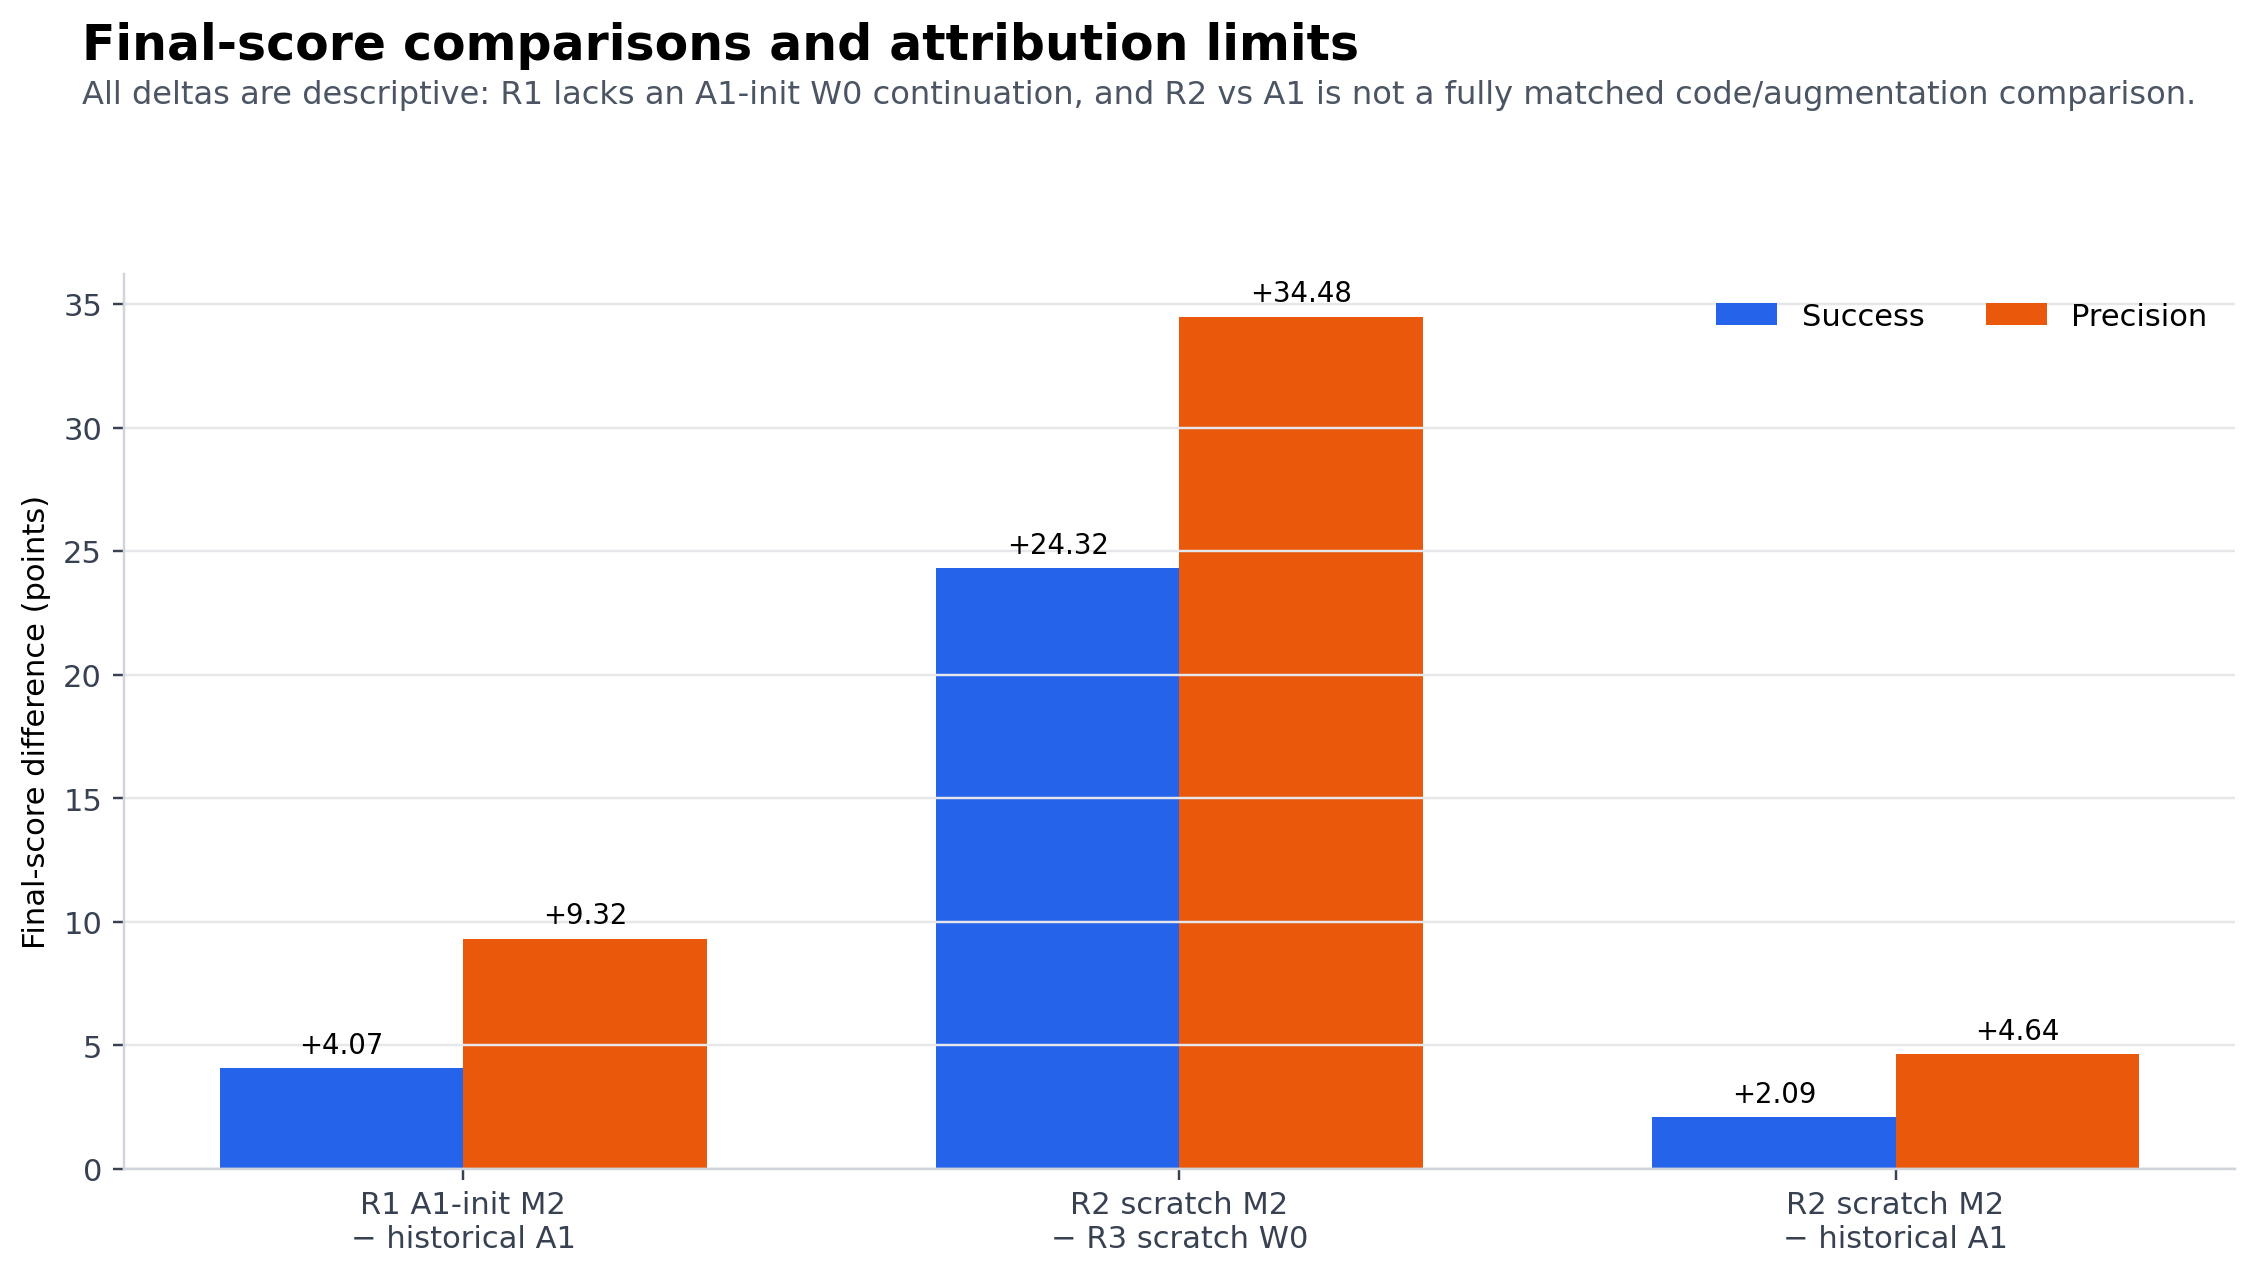

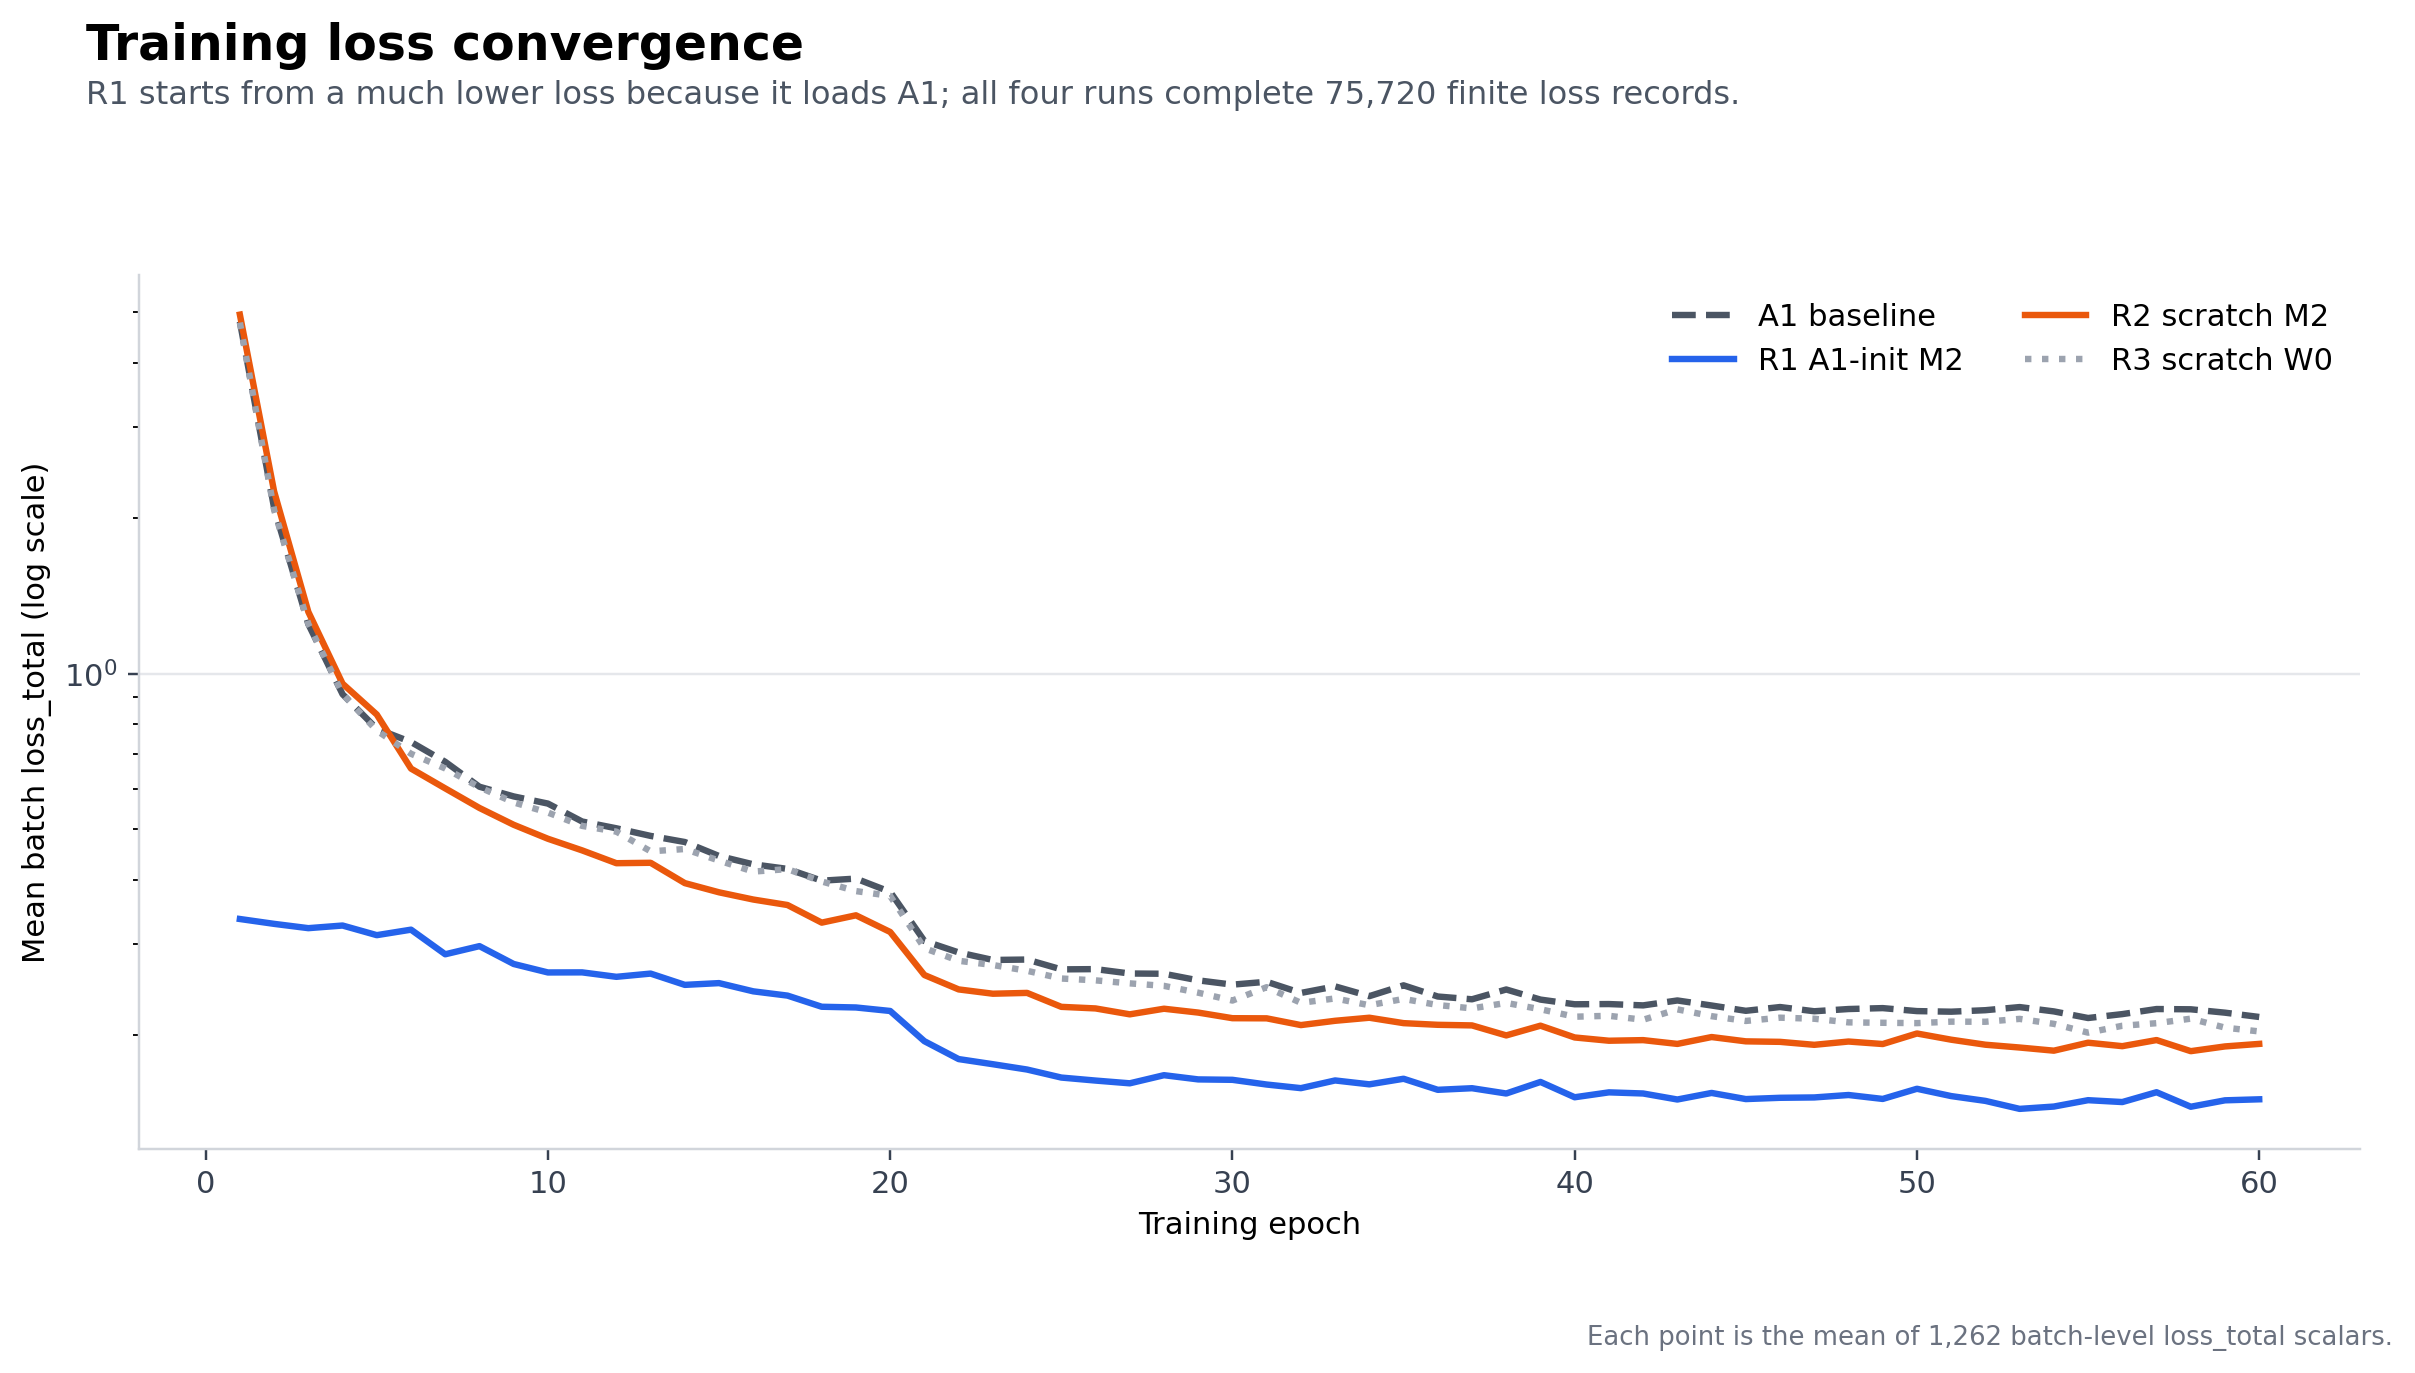

In [4]:
for path in outputs['figure_paths']:
    display(Image(filename=str(path)))